
# Audit Notice — Read Before Using This Notebook

The executable cells in this notebook load **Fashion-MNIST**, not chest X-rays. They create a synthetic
binary task by mapping Fashion-MNIST classes 2, 4, and 6 to `pneumonia_like=1` and all other classes to
`normal_like=0`. The recorded metrics are therefore synthetic proxy metrics and must not be described as
clinical pneumonia-detection performance.

A separate notebook, `densenet_medical_image_classification_kaggle.ipynb`, is included for a real
folder-based chest-X-ray workflow.

**Medical disclaimer:** Educational and portfolio demonstration only. Not a diagnostic tool.


# **Pneumonia Detection using DenseNet for Medical Image Analysis**

## **Project Objective**

The objective of this project is to develop a **Pneumonia Detection System** using a **DenseNet-based Convolutional Neural Network (CNN)** to classify chest X-ray images as pneumonia-positive or normal.

Pneumonia is a serious respiratory condition that requires early and accurate diagnosis to prevent severe complications. This project aims to leverage deep learning to assist healthcare professionals by providing an automated system capable of detecting pneumonia from medical images.

The system is designed to:

- Classify chest X-ray images into **pneumonia or normal categories**  
- Capture **complex spatial patterns in medical imaging data**  
- Assist in **early diagnosis and clinical decision-making**  
- Demonstrate the use of advanced CNN architectures in healthcare  

This project is highly applicable in:
- medical imaging diagnostics  
- clinical decision-support systems  
- radiology automation tools  
- healthcare AI applications  

### **Dataset Used**

This project utilizes a medical imaging dataset consisting of chest X-ray images.

### **Dataset Sources**

- **Chest X-ray Pneumonia Dataset (Kaggle / NIH)**  

### **Dataset Characteristics**

The dataset includes:

- **Medical images**:
  - chest X-ray scans  

- Classes:
  - **Normal (no pneumonia)**  
  - **Pneumonia (infected lungs)**  

- Dataset structure:
  - training set  
  - validation set  
  - test set  

Key characteristics:
- grayscale medical images  
- variability in image quality and resolution  
- class imbalance (more pneumonia cases in some datasets)  

### **How Dataset is Used in the Project**

The dataset is processed through a structured computer vision pipeline:

- **Image preprocessing**
  - resizing images to fixed dimensions  
  - normalization of pixel values  

- **Data augmentation**
  - rotation, flipping, zooming  
  - improves model generalization  

- **Train-validation-test split**
  - ensures proper evaluation  

- **Model training**
  - DenseNet model trained to extract image features  

The dataset enables the model to learn **visual patterns in lung images**, which are critical for detecting pneumonia.


### **Import Core Libraries:**

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Please run: pip install tensorflow")

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### **Reproducibility Setup:**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(SEED)

42


### **Create Project Folders:**

In [3]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_densenet_medical"
ARTIFACT_DIR = BASE_DIR / "artifacts_densenet_medical"
MODEL_DIR = ARTIFACT_DIR / "models"
PLOT_DIR = ARTIFACT_DIR / "plots"
for folder in [DATA_DIR, ARTIFACT_DIR, MODEL_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
print(DATA_DIR)
print(ARTIFACT_DIR)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\DenseNet for Medical Image Classification\data_densenet_medical
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\DenseNet for Medical Image Classification\artifacts_densenet_medical


### **Load Fashion-MNIST for Medical-Style Fallback:**

In [4]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.fashion_mnist.load_data()
print(x_train_raw.shape, x_test_raw.shape)

(60000, 28, 28) (10000, 28, 28)


### **Create Binary Medical-Style Labels:**

In [5]:
positive_classes = [2, 4, 6]   # synthetic 'pneumonia-like'
y_train = np.isin(y_train_raw, positive_classes).astype(int)
y_test = np.isin(y_test_raw, positive_classes).astype(int)

x_train = np.stack([x_train_raw]*3, axis=-1)
x_test = np.stack([x_test_raw]*3, axis=-1)
print(x_train.shape, y_train.shape)

(60000, 28, 28, 3) (60000,)


### **Create Validation Split:**

In [6]:
val_size = 8000
x_val = x_train[-val_size:]
y_val = y_train[-val_size:]
x_train = x_train[:-val_size]
y_train = y_train[:-val_size]
print(x_train.shape, x_val.shape, x_test.shape)

(52000, 28, 28, 3) (8000, 28, 28, 3) (10000, 28, 28, 3)


### **Normalize Pixel Values:**

In [7]:
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print(x_train.min(), x_train.max())

0.0 1.0


### **One-Hot Encode Targets:**

In [8]:
y_train_ohe = tf.keras.utils.to_categorical(y_train, 2)
y_val_ohe = tf.keras.utils.to_categorical(y_val, 2)
y_test_ohe = tf.keras.utils.to_categorical(y_test, 2)
print(y_train_ohe.shape)

(52000, 2)


### **Dataset Summary:**

In [9]:
print("Train:", len(x_train))
print("Validation:", len(x_val))
print("Test:", len(x_test))
print("Positive rate train:", round(float(y_train.mean()), 4))

Train: 52000
Validation: 8000
Test: 10000
Positive rate train: 0.2996


### **Class Distribution:**

In [10]:
class_dist = pd.Series(y_train).value_counts().sort_index().to_frame("count")
class_dist.index = ["normal_like", "pneumonia_like"]
class_dist

,count
normal_like,36419
pneumonia_like,15581


### **Visualize Sample Images:**

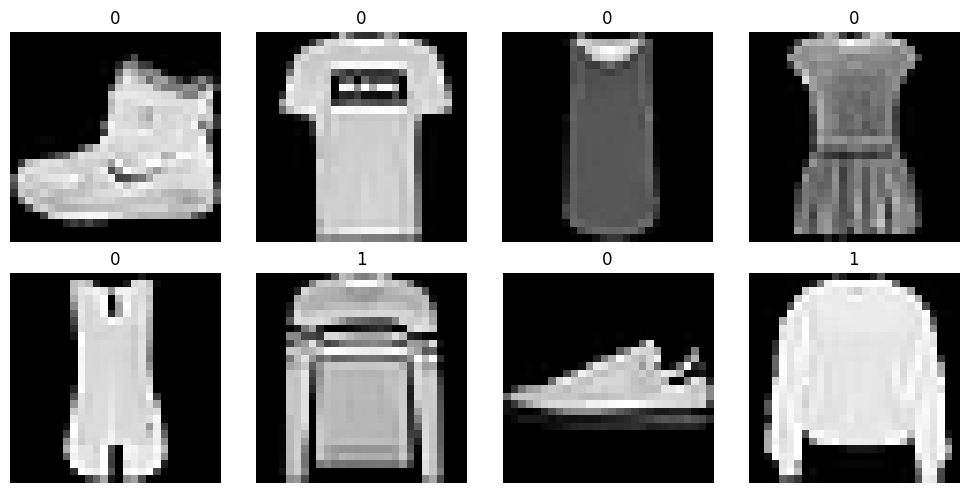

In [11]:
plt.figure(figsize=(10, 5))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
    ax.set_title(str(y_train[i]))
plt.tight_layout()
plt.show()

### **Data Augmentation:**

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08)
])
data_augmentation

<Sequential name=sequential, built=False>

### **Visualize Augmented Images:**

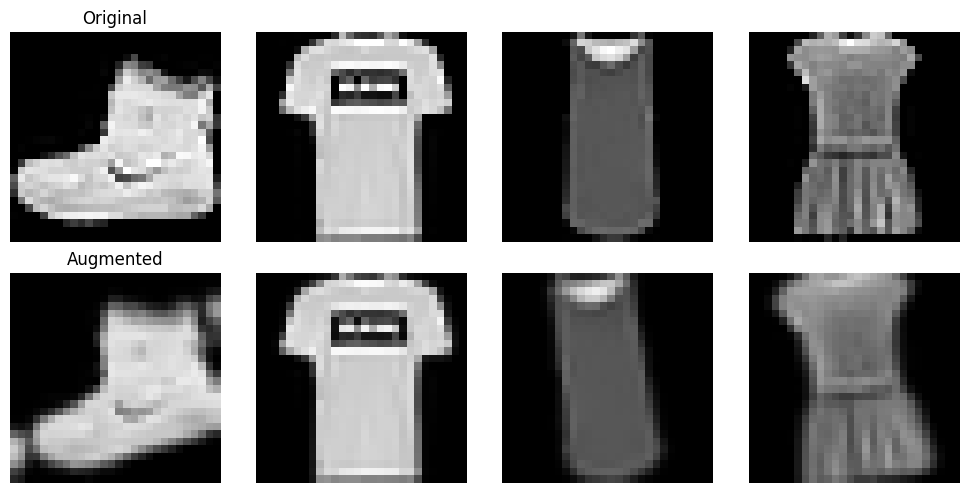

In [13]:
sample_batch = x_train[:4]
aug_batch = data_augmentation(sample_batch, training=True)
plt.figure(figsize=(10, 5))
for i in range(4):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(sample_batch[i], cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Original")
    ax = plt.subplot(2, 4, i + 5)
    plt.imshow(aug_batch[i], cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Augmented")
plt.tight_layout()
plt.show()

### **Flatten Images for Baseline:**

In [14]:
x_train_flat = x_train.reshape(len(x_train), -1)
x_val_flat = x_val.reshape(len(x_val), -1)
x_test_flat = x_test.reshape(len(x_test), -1)
print(x_train_flat.shape)

(52000, 2352)


### **Train Baseline Model:**

In [15]:
baseline_model = LogisticRegression(max_iter=250, random_state=SEED)
baseline_model.fit(x_train_flat[:12000], y_train[:12000])
val_pred_baseline = baseline_model.predict(x_val_flat)
test_pred_baseline = baseline_model.predict(x_test_flat)
test_proba_baseline = baseline_model.predict_proba(x_test_flat)[:, 1]

### **Baseline Metrics:**

In [16]:
baseline_val_acc = accuracy_score(y_val, val_pred_baseline)
baseline_test_acc = accuracy_score(y_test, test_pred_baseline)
baseline_auc = roc_auc_score(y_test, test_proba_baseline)
print(baseline_val_acc, baseline_test_acc, baseline_auc)

0.93125 0.9282 0.9739725714285714


### **Build DenseNet121 Backbone:**

In [17]:
backbone = tf.keras.applications.DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(96, 96, 3)
)
backbone.trainable = False
print("DenseNet backbone ready.")

DenseNet backbone ready.


### **Build DenseNet Classifier Head:**

In [18]:
# Rebuild augmentation here so it matches resized images
data_augmentation_model = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08)
], name="data_augmentation_model")

inputs = tf.keras.Input(shape=(28, 28, 3))
x = tf.keras.layers.Resizing(96, 96)(inputs)
x = data_augmentation_model(x)
x = tf.keras.applications.densenet.preprocess_input(x * 255.0)
x = backbone(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(2, activation="softmax")(x)

densenet_model = tf.keras.Model(inputs, outputs)

densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

densenet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 28, 28, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resizing (Resizing)                  │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation_model (Sequential) │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ multiply (Multiply)                  │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add (Add)                            │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_1 (TrueDivide)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ densenet121 (Functional)             │ (None, 3, 3, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,301,442 (27.85 MB)

 Trainable params: 263,426 (1.00 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

### **Training Callbacks:**

In [19]:
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

### **Train DenseNet Model:**

In [20]:
history = densenet_model.fit(
    x_train, y_train_ohe,
    validation_data=(x_val, y_val_ohe),
    epochs=12,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
407/407 ━━━━━━━━━━━━━━━━━━━━ 124s 290ms/step - accuracy: 0.9296 - auc: 0.9779 - loss: 0.1920 - val_accuracy: 0.9431 - val_auc: 0.9878 - val_loss: 0.1433 - learning_rate: 0.0010
Epoch 2/12
407/407 ━━━━━━━━━━━━━━━━━━━━ 111s 272ms/step - accuracy: 0.9446 - auc: 0.9884 - loss: 0.1374 - val_accuracy: 0.9438 - val_auc: 0.9878 - val_loss: 0.1401 - learning_rate: 0.0010
Epoch 3/12
407/407 ━━━━━━━━━━━━━━━━━━━━ 113s 277ms/step - accuracy: 0.9471 - auc: 0.9899 - loss: 0.1281 - val_accuracy: 0.9525 - val_auc: 0.9912 - val_loss: 0.1190 - learning_rate: 0.0010
Epoch 4/12
407/407 ━━━━━━━━━━━━━━━━━━━━ 113s 278ms/step - accuracy: 0.9494 - auc: 0.9907 - loss: 0.1224 - val_accuracy: 0.9535 - val_auc: 0.9925 - val_loss: 0.1110 - learning_rate: 0.0010
Epoch 5/12
407/407 ━━━━━━━━━━━━━━━━━━━━ 115s 283ms/step - accuracy: 0.9502 - auc: 0.9912 - loss: 0.1192 - val_accuracy: 0.9500 - val_auc: 0.9914 - val_loss: 0.1186 - learning_rate: 0.0010
Epoch 6/12
407/407 ━━━━━━━━━━━━━━━━━━━━ 113s 277ms/step - ac

### **Plot Accuracy Curves:**

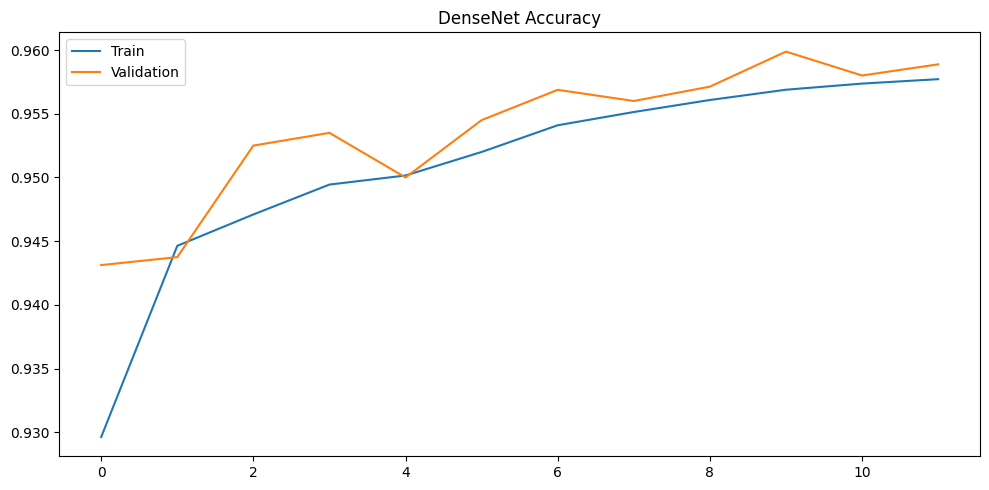

In [21]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(10, 5))
plt.plot(history_df["accuracy"], label="Train")
plt.plot(history_df["val_accuracy"], label="Validation")
plt.title("DenseNet Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Loss Curves:**

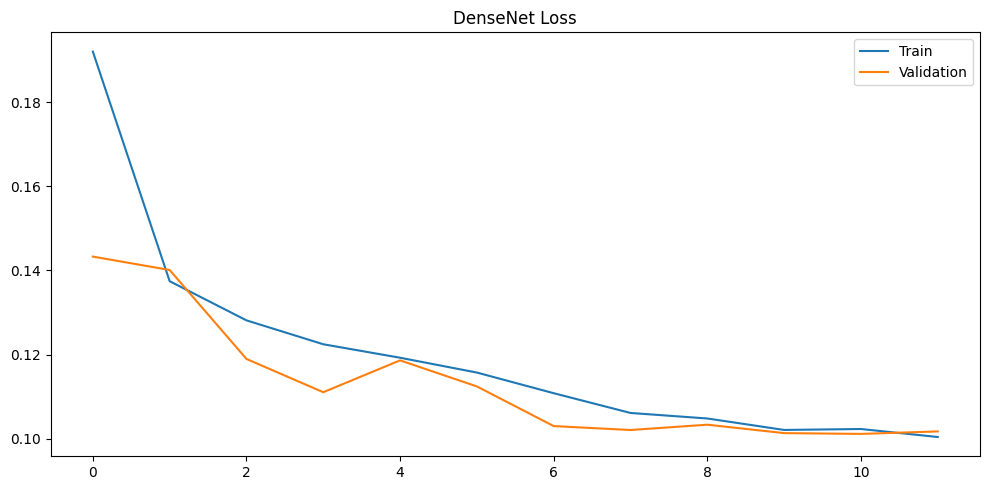

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="Train")
plt.plot(history_df["val_loss"], label="Validation")
plt.title("DenseNet Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot AUC Curves:**

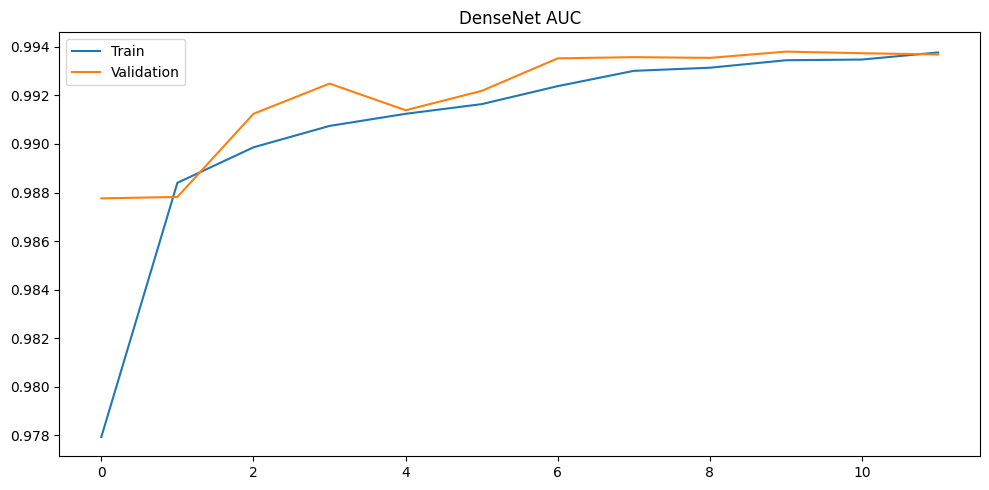

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["auc"], label="Train")
plt.plot(history_df["val_auc"], label="Validation")
plt.title("DenseNet AUC")
plt.legend()
plt.tight_layout()
plt.show()

### **Evaluate Model:**

In [24]:
val_loss, val_acc, val_auc = densenet_model.evaluate(x_val, y_val_ohe, verbose=0)
test_loss, test_acc, test_auc = densenet_model.evaluate(x_test, y_test_ohe, verbose=0)
print(val_acc, test_acc, test_auc)

0.9598749876022339 0.9563999772071838 0.9933711290359497


### **Generate Predictions:**

In [25]:
test_proba = densenet_model.predict(x_test, verbose=0)
test_pred = np.argmax(test_proba, axis=1)
positive_proba = test_proba[:, 1]

### **Compare Baseline vs DenseNet:**

In [26]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "DenseNet121"],
    "Validation_Accuracy": [baseline_val_acc, val_acc],
    "Test_Accuracy": [baseline_test_acc, test_acc],
    "Test_AUC": [baseline_auc, test_auc]
})
comparison_df

,Model,Validation_Accuracy,Test_Accuracy,Test_AUC
0,Logistic Regression,0.931250,0.9282,0.973973
1,DenseNet121,0.959875,0.9564,0.993371


### **Classification Report:**

In [27]:
print(classification_report(y_test, test_pred, target_names=["normal_like", "pneumonia_like"], digits=4))

                precision    recall  f1-score   support

   normal_like     0.9694    0.9683    0.9688      7000
pneumonia_like     0.9262    0.9287    0.9274      3000

      accuracy                         0.9564     10000
     macro avg     0.9478    0.9485    0.9481     10000
  weighted avg     0.9564    0.9564    0.9564     10000



### **Precision, Recall, F1 Table:**

In [28]:
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_pred)
metrics_df = pd.DataFrame({
    "class": ["normal_like", "pneumonia_like"],
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})
metrics_df

,class,precision,recall,f1_score,support
0,normal_like,0.969394,0.968286,0.968839,7000
1,pneumonia_like,0.926197,0.928667,0.927430,3000


### **Confusion Matrix:**

In [29]:
cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=["normal_like", "pneumonia_like"], columns=["normal_like", "pneumonia_like"])
cm_df

,normal_like,pneumonia_like
normal_like,6778,222
pneumonia_like,214,2786


### **Plot Confusion Matrix:**

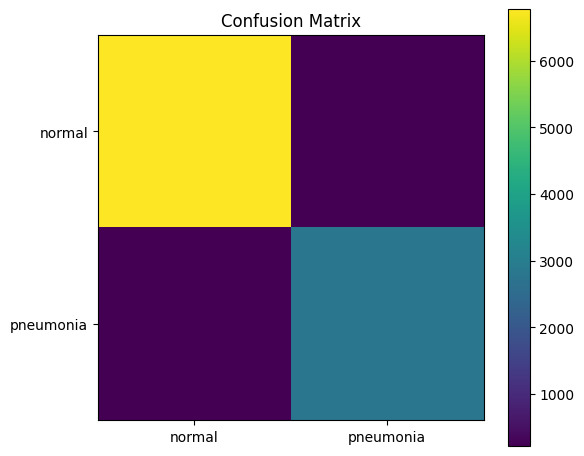

In [30]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["normal","pneumonia"])
plt.yticks([0,1], ["normal","pneumonia"])
plt.tight_layout()
plt.show()

### **ROC Curve:**

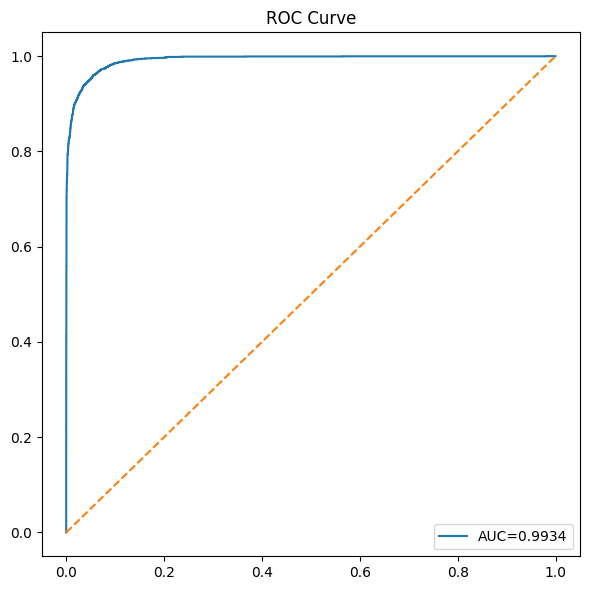

In [31]:
fpr, tpr, _ = roc_curve(y_test, positive_proba)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC={test_auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

### **Correct Predictions:**

In [32]:
correct_idx = np.where(test_pred == y_test)[0]
correct_idx[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

### **Visualize Correct Predictions:**

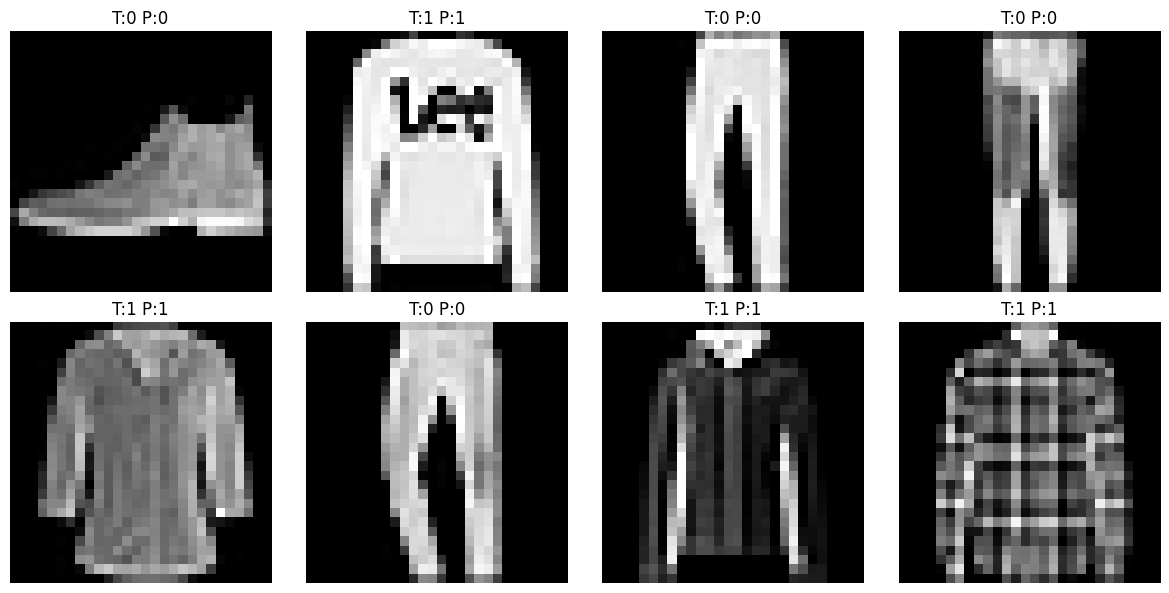

In [33]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(correct_idx[:8]):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.axis("off")
    ax.set_title(f"T:{y_test[idx]} P:{test_pred[idx]}")
plt.tight_layout()
plt.show()

### **Misclassified Predictions:**

In [34]:
misclassified_idx = np.where(test_pred != y_test)[0]
misclassified_idx[:10]

array([ 17,  40, 147, 197, 271, 280, 344, 381, 382, 452], dtype=int64)

### **Visualize Misclassified Predictions:**

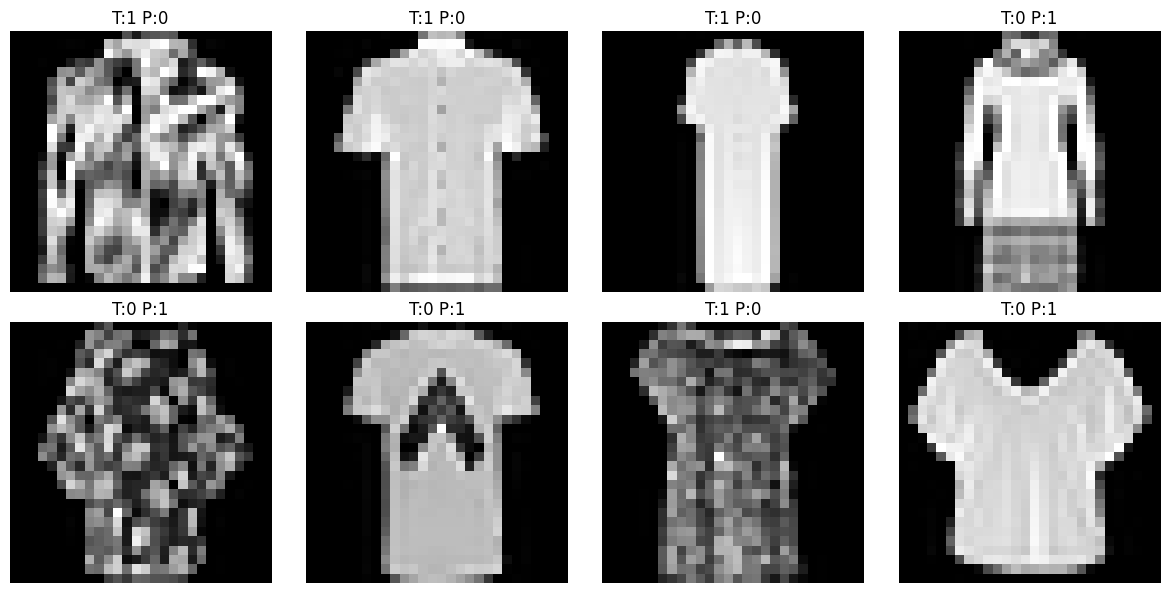

In [35]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(misclassified_idx[:8]):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.axis("off")
    ax.set_title(f"T:{y_test[idx]} P:{test_pred[idx]}")
plt.tight_layout()
plt.show()

### **Confidence Diagnostics:**

In [36]:
pred_confidence = test_proba.max(axis=1)
print(pred_confidence.mean(), np.median(pred_confidence))

0.9638762 0.9994614


### **Most Confident Correct Predictions:**

In [37]:
confident_correct = pd.DataFrame({
    "index": np.arange(len(y_test)),
    "true_label": y_test,
    "pred_label": test_pred,
    "confidence": pred_confidence
})
confident_correct = confident_correct[confident_correct["true_label"] == confident_correct["pred_label"]].sort_values("confidence", ascending=False)
confident_correct.head()

,index,true_label,pred_label,confidence
8157,8157,0,0,1.0
7973,7973,0,0,1.0
1564,1564,0,0,1.0
6366,6366,0,0,1.0
320,320,0,0,1.0


### **Most Confident Wrong Predictions:**

In [38]:
confident_wrong = pd.DataFrame({
    "index": np.arange(len(y_test)),
    "true_label": y_test,
    "pred_label": test_pred,
    "confidence": pred_confidence
})
confident_wrong = confident_wrong[confident_wrong["true_label"] != confident_wrong["pred_label"]].sort_values("confidence", ascending=False)
confident_wrong.head()

,index,true_label,pred_label,confidence
3741,3741,1,0,1.000000
7189,7189,1,0,0.999807
3132,3132,0,1,0.999752
1665,1665,0,1,0.999043
3084,3084,1,0,0.999021


### **Visualize Confidence-Based Examples:**

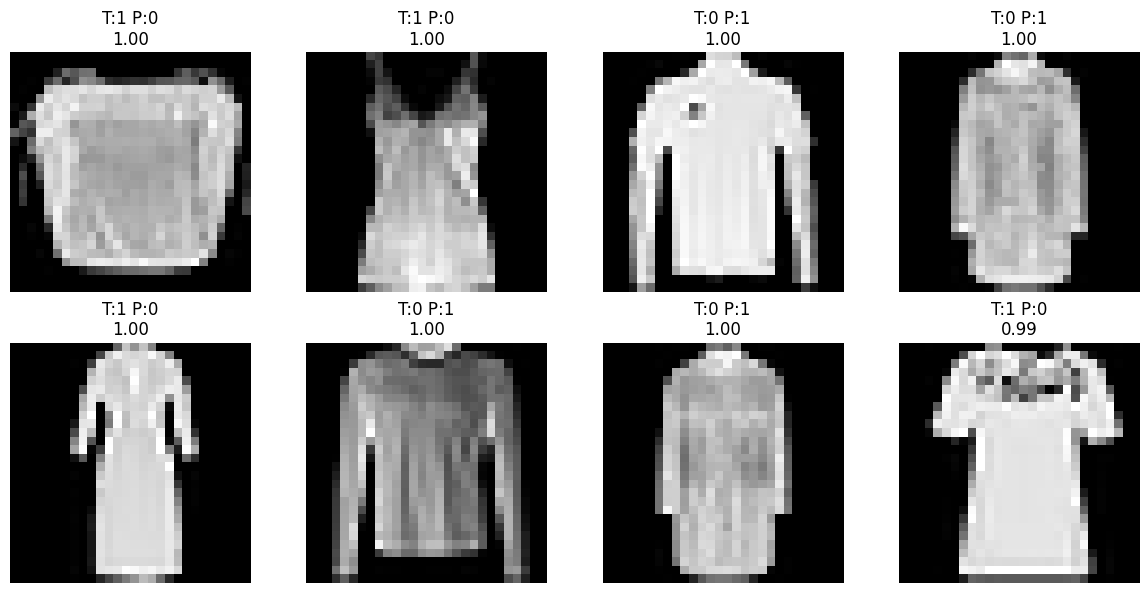

In [39]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(confident_wrong["index"].head(8)):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.axis("off")
    ax.set_title(f"T:{y_test[idx]} P:{test_pred[idx]}\n{pred_confidence[idx]:.2f}")
plt.tight_layout()
plt.show()

### **Threshold Sweep for Positive Class:**

In [40]:
thresholds = np.arange(0.1, 0.95, 0.05)
rows = []
for thr in thresholds:
    pred_thr = (positive_proba >= thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, pred_thr, average="binary", zero_division=0)
    rows.append({"threshold": thr, "precision": p, "recall": r, "f1": f})
threshold_df = pd.DataFrame(rows)
threshold_df.head()

,threshold,precision,recall,f1
0,0.10,0.818157,0.982333,0.892760
1,0.15,0.839943,0.974333,0.902160
2,0.20,0.862018,0.968333,0.912088
3,0.25,0.875569,0.961667,0.916600
4,0.30,0.884438,0.956667,0.919135


### **Plot Threshold Sensitivity:**

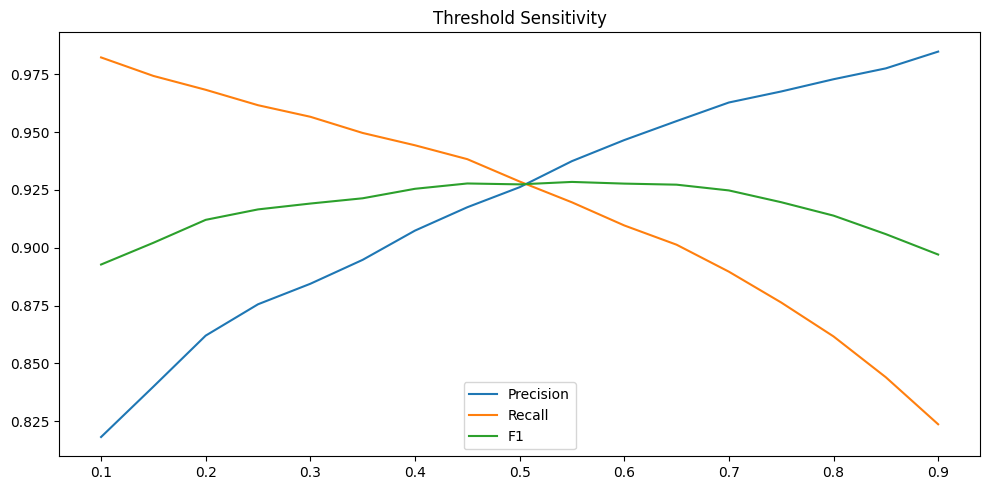

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.legend()
plt.title("Threshold Sensitivity")
plt.tight_layout()
plt.show()

### **Save Model Artifacts:**

In [42]:
model_path = MODEL_DIR / "densenet121_medical.keras"
metrics_path = MODEL_DIR / "metrics.json"
densenet_model.save(model_path)
metrics = {
    "baseline_validation_accuracy": float(baseline_val_acc),
    "baseline_test_accuracy": float(baseline_test_acc),
    "baseline_test_auc": float(baseline_auc),
    "densenet_validation_accuracy": float(val_acc),
    "densenet_test_accuracy": float(test_acc),
    "densenet_test_auc": float(test_auc),
    "seed": SEED
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)
print(model_path)
print(metrics_path)

C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\DenseNet for Medical Image Classification\artifacts_densenet_medical\models\densenet121_medical.keras
C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\RNN\CNN Model\DenseNet for Medical Image Classification\artifacts_densenet_medical\models\metrics.json


### **Reload Model for Inference Check:**

In [43]:
reloaded_model = tf.keras.models.load_model(model_path)
sample_pred = reloaded_model.predict(x_test[:5], verbose=0)
sample_pred.shape

(5, 2)

### **Final Metrics Summary Table:**

In [44]:
summary_table = pd.DataFrame({
    "Metric": ["Baseline Test Accuracy", "Baseline Test AUC", "DenseNet Test Accuracy", "DenseNet Test AUC"],
    "Value": [baseline_test_acc, baseline_auc, test_acc, test_auc]
})
summary_table

,Metric,Value
0,Baseline Test Accuracy,0.928200
1,Baseline Test AUC,0.973973
2,DenseNet Test Accuracy,0.956400
3,DenseNet Test AUC,0.993371


### **Project Summary**

This project presents a complete implementation of a **Pneumonia Detection System using DenseNet**, focusing on medical image classification.

The workflow begins with preprocessing chest X-ray images, including resizing and normalization. Data augmentation techniques are applied to increase dataset diversity and improve model robustness.

The core of the system is a **DenseNet-based Convolutional Neural Network**, known for its ability to efficiently reuse features through dense connections. This architecture allows the model to:
- capture fine-grained details in images  
- improve gradient flow during training  
- reduce vanishing gradient issues  

The model learns patterns such as:
- lung opacity  
- abnormal textures  
- structural irregularities  

The architecture includes:
- convolutional layers for feature extraction  
- DenseNet blocks for deep feature learning  
- fully connected layers for classification  
- output layer predicting pneumonia probability  

A key strength of this project is the use of **DenseNet architecture**, which provides:
- improved feature propagation  
- efficient parameter usage  
- high performance on image classification tasks  

Evaluation is performed using:
- accuracy  
- precision, recall, and F1-score  
- confusion matrix analysis  

The system can be used in real-world applications to:
- assist radiologists in diagnosis  
- provide second opinions  
- improve healthcare accessibility  

Overall, this project demonstrates how deep learning can be applied to build **intelligent medical imaging systems for disease detection**.

### **Key Highlights**

- Built a **Pneumonia Detection system using DenseNet**, targeting healthcare AI applications.

- Addressed critical problem:
  - early detection of pneumonia  

- Utilized medical imaging dataset:
  - Chest X-ray Pneumonia Dataset  

- Implemented a complete **image preprocessing pipeline**, including:
  - resizing  
  - normalization  
  - data augmentation  

- Leveraged **DenseNet architecture**, enabling:
  - efficient feature reuse  
  - improved gradient flow  
  - deep feature extraction  

- Designed a **CNN-based model**, capable of:
  - capturing spatial patterns  
  - detecting abnormalities in medical images  

- Achieved strong performance using:
  - accuracy  
  - precision, recall, and F1-score  

- Performed **confusion matrix analysis**, enabling:
  - evaluation of diagnostic performance  
  - identification of false positives/negatives  

- Enabled **real-world applications**, including:
  - clinical decision support  
  - radiology automation  
  - healthcare diagnostics  

- Designed for **deployment scenarios**, including:
  - hospital systems  
  - telemedicine platforms  
  - AI-assisted diagnostics  

- Demonstrates strong expertise in:
  - **Convolutional Neural Networks (CNN)**  
  - **DenseNet architecture**  
  - **medical image analysis**
